In [1]:
import pickle
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pandas as pd
from tqdm.contrib.concurrent import process_map
import tqdm

In [2]:
# Define the experiment parameters here
num_samples = 41267
yearlist = np.arange(2013, 2015)
preprocessed_path = './processed_data_base'
num_workers = 2

In [3]:
# Load and combine files
features = []
for year in yearlist:
    features_year = pickle.load(open(os.path.join(preprocessed_path, f'train_data_{year}.p'), 'rb'))
    features.extend(features_year)

In [4]:
# Sample data points from combined data
sampled_values = np.random.choice(np.arange(0, len(features)), size = (num_samples, ), replace = False)

In [5]:
# Get dbn and dbe values for the sampled data points
data_dbn = []
data_dbe = []
for key in sampled_values:
    data_dbn.extend(features[key]['future_supermag'][0, :, 3])
    data_dbe.extend(features[key]['future_supermag'][0, :, 2])

In [6]:
# Normalize and clean data
data_dbn = np.array(data_dbn)
data_dbe = np.array(data_dbe)
data_dbn_norm = np.abs(data_dbn)
data_dbe_norm = np.abs(data_dbe)
data_dbn_norm[np.isnan(data_dbn_norm)] = 0
data_dbe_norm[np.isnan(data_dbe_norm)] = 0
data_dbn_mean, data_dbn_std = np.mean(data_dbn_norm), np.std(data_dbn_norm)
data_dbe_mean, data_dbe_std = np.mean(data_dbe_norm), np.std(data_dbe_norm)
data_dbn_norm = (data_dbn_norm - data_dbn_mean) / data_dbn_std
data_dbe_norm = (data_dbe_norm - data_dbe_mean) / data_dbe_std

In [7]:
# Function to visualize cluster densities

def visualize_density_plots(data, labels):
    filtered_label0 = data[labels == 0]
    filtered_label1 = data[labels == 1]
    
    sampled_idx0 = np.random.choice(np.arange(0, len(filtered_label0)), size = (500, ), replace = False)
    sampled_idx1 = np.random.choice(np.arange(0, len(filtered_label1)), size = (500, ), replace = False)
    filtered_label0 = filtered_label0[sampled_idx0]
    filtered_label1 = filtered_label1[sampled_idx1]

    combined_data = np.concatenate((filtered_label0 , filtered_label1))
    combined_labels = np.array(["Quiet Time" for _ in filtered_label0] + ["Storm Time" for _ in filtered_label1])
    
    df = pd.DataFrame()
    df['Data dbn'] = combined_data
    df['Labels'] = combined_labels
    sns.set_style("darkgrid")
    sns.kdeplot(data=df, x="Data dbn", hue='Labels',fill=True, common_norm=False,
   alpha=.5, linewidth=0).set(title='Storm Time vs Quiet Time Density')

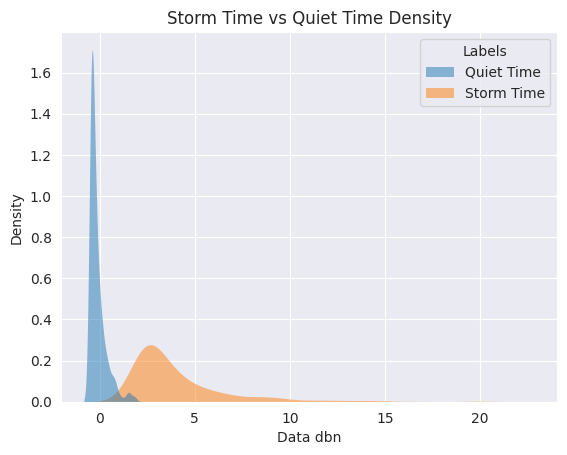

In [8]:
# Perform clustering for dbe
kmeans_dbe = KMeans(init="k-means++", n_clusters=2, n_init=4, random_state=0)
label_dbe = kmeans_dbe.fit_predict(data_dbe_norm.reshape(-1, 1))

visualize_density_plots(data_dbe_norm, label_dbe)

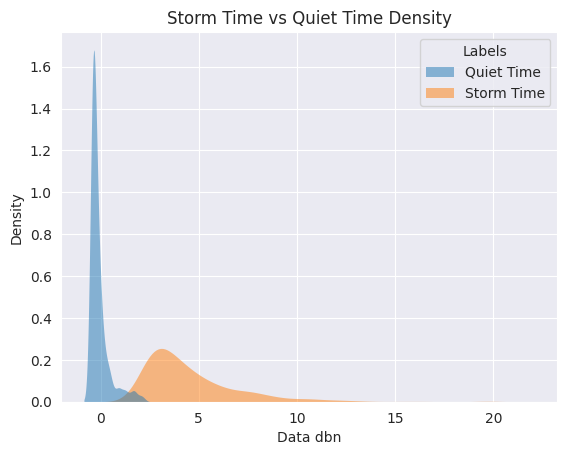

In [9]:
# Perform clustering for dbn
kmeans_dbn = KMeans(init="k-means++", n_clusters=2, n_init=4, random_state=0)
label_dbn = kmeans_dbn.fit_predict(data_dbn_norm.reshape(-1, 1))

visualize_density_plots(data_dbn_norm, label_dbn)

In [10]:
# Find majority class and density function

def majority_class_density(labels):
    filtered_labels_0 = labels[labels == 0]
    filtered_labels_1 = labels[labels == 1]
    if len(filtered_labels_0) > len(filtered_labels_1):
        majority_class = 0
        class_density = len(filtered_labels_0) / (len(filtered_labels_0) + len(filtered_labels_1))
    else:
        majority_class = 1
        class_density = len(filtered_labels_1) / (len(filtered_labels_0) + len(filtered_labels_1))
    return majority_class, class_density

In [11]:
# Find the class and density
majority_class_dbe, density_dbe = majority_class_density(label_dbe)
majority_class_dbn, density_dbn = majority_class_density(label_dbn)
weight_minority_class_dbe = density_dbe / (1 - density_dbe)
weight_minority_class_dbn = density_dbn / (1 - density_dbn)

In [12]:
majority_class_dbe, weight_minority_class_dbe

(0, 27.658662412546487)

In [13]:
majority_class_dbn, weight_minority_class_dbn

(0, 33.71265555678388)

In [17]:
# Function to add labels and weights

def get_scores(kmeans, data):
    cluster_centers = kmeans.cluster_centers_
    main_cluster_center = None
    if cluster_centers[0] > cluster_centers[1]:
        main_cluster_center = cluster_centers[0]
    else:
        main_cluster_center = cluster_centers[1]
    distance = (data - main_cluster_center) * (data - main_cluster_center)
    score = distance/16000
    return score

def process_data(dbn, dbe):
    
    dbn = np.abs(dbn)
    dbe = np.abs(dbe)
    dbn[np.isnan(dbn)] = 0
    dbe[np.isnan(dbe)] = 0
    dbn = (dbn - data_dbn_mean) / data_dbn_std
    dbe = (dbe - data_dbe_mean) / data_dbe_std
    
    labels_dbe = kmeans_dbe.predict(dbe.reshape((-1,1)))
    labels_dbn = kmeans_dbn.predict(dbn.reshape((-1, 1)))
    
    scores_dbe = get_scores(kmeans_dbe, dbe[labels_dbe != majority_class_dbe])
    scores_dbn = get_scores(kmeans_dbn, dbn[labels_dbn != majority_class_dbn])
    
    weights_dbe = np.ones_like(dbe)
    weights_dbn = np.ones_like(dbn)
    
    weights_dbe[labels_dbe != majority_class_dbe] = 1 + weight_minority_class_dbe * scores_dbe
    weights_dbn[labels_dbn != majority_class_dbn] = 1 + weight_minority_class_dbn * scores_dbn
    
    return weights_dbe, weights_dbn
    

<Axes: xlabel='data', ylabel='weights'>

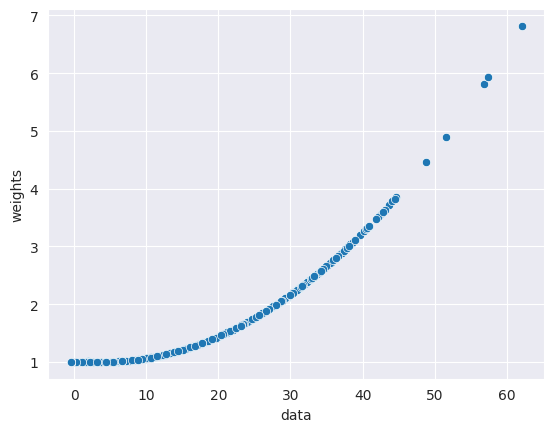

In [19]:
weights_dbe, weights_dbn = process_data(data_dbn, data_dbe)
df = pd.DataFrame()
sampled_values = np.random.choice(np.arange(0, len(data_dbe_norm)), size = (5000, ), replace = False)
df["data"] = data_dbe_norm
df["weights"] = weights_dbe
sns.scatterplot(data=df, x="data", y="weights")

<Axes: xlabel='data', ylabel='weights'>

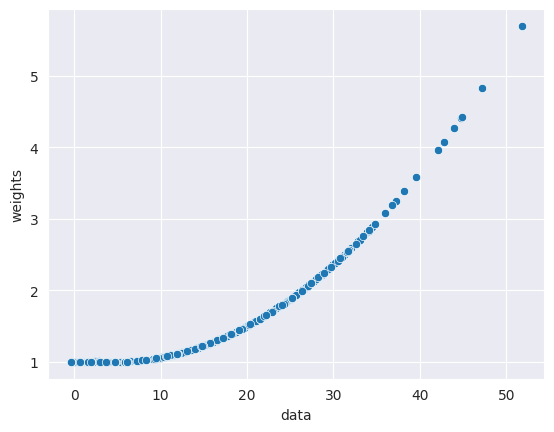

In [21]:
df["data"] = data_dbn_norm
df["weights"] = weights_dbn
sns.scatterplot(data=df, x="data", y="weights")

In [22]:
del features

In [23]:
for year in yearlist:
    features_year = pickle.load(open(os.path.join(preprocessed_path, f'train_data_{year}.p'), 'rb'))
    new_features_year = []
    dbn = []
    dbe = []
    #features_list = process_map(process_data, [features_year[i] for i in range(len(features_year))], max_workers = num_workers, chunksize = 256)
    for feature_dict in tqdm.tqdm(features_year):
        dbn.extend(feature_dict['future_supermag'][0, :, 3])
        dbe.extend(feature_dict['future_supermag'][0, :, 2])
    
    weights_dbe, weights_dbn = process_data(dbn, dbe)
    weights_dbe = weights_dbe.reshape((len(features_year), -1))
    weights_dbn = weights_dbn.reshape((len(features_year), -1))
    print(weights_dbe.shape, weights_dbn.shape)
    for i in tqdm.trange(len(features_year)):
        features_dict = features_year[i]
        features_dict['weight_dbe'] = weights_dbe[i]
        features_dict['weight_dbn'] = weights_dbn[i]
        new_features_year.append(features_dict)
        
    with open(os.path.join(preprocessed_path, f'train_with_weights_data_{year}.p'), 'wb') as f:
        pickle.dump(new_features_year, f, pickle.HIGHEST_PROTOCOL)


100%|██████████| 412674/412674 [00:10<00:00, 40167.51it/s]


(412674, 175) (412674, 175)


100%|██████████| 412674/412674 [00:09<00:00, 45772.78it/s]


(412674, 175) (412674, 175)


100%|██████████| 412674/412674 [00:00<00:00, 771629.62it/s]
